### Bloc 1 - Analyse exploratoire des données pour modélisation ML
1) Chargement du fichier
2) Fonction informative du dataset et affichage
3) Identification et selection des bâtiments qui ne sont pas dédié exclusivement à l'habitation



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 

#### 1) Chargement du fichier à la racine du repertoire data


In [2]:
data = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

#### 2) Fonction informative du dataset et affichage

In [3]:
def info(df, name):
    print(f"Dataset: {name} - {df.shape[0]} rows {df.shape[1]} columns")
    profil = pd.DataFrame({ 
        'columns': df.columns.values,
        'non_null': df.notnull().sum().values,
        'nan': df.isna().sum().values,
        'nan %': (df.isna().sum() / len(df) * 100).values.round(0), 
        'unique':df.nunique().values,
        'types':df.dtypes.values,
        'types_size': df.apply(lambda col:(col.astype(str).str.len().max())).values
    })
    return profil
    

In [4]:
info(data, 'Seattle 2016')

Dataset: Seattle 2016 - 3376 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_size
0,OSEBuildingID,3376,0,0.0,3376,int64,5.0
1,DataYear,3376,0,0.0,1,int64,4.0
2,BuildingType,3376,0,0.0,8,str,20.0
3,PrimaryPropertyType,3376,0,0.0,24,str,27.0
4,PropertyName,3376,0,0.0,3362,str,72.0
5,Address,3376,0,0.0,3354,str,41.0
6,City,3376,0,0.0,1,str,7.0
7,State,3376,0,0.0,1,str,2.0
8,ZipCode,3360,16,0.0,55,float64,7.0
9,TaxParcelIdentificationNumber,3376,0,0.0,3268,str,25.0


#### 3) Identification et selection des bâtiments qui ne sont pas dédié exclusivement à l'habitation

In [5]:
# In identifie ce qu'il y a dans cette colonne afin de selectionner ce qui est pertinent
data['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [6]:
# On instancie un nouveau df avec les batiments que l'on a selectionner dans cette colonne, et on affiche les infos pour constater le résultat
df_NonResidential = data[data['BuildingType'].isin(['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus'])]
info(df_NonResidential, 'Seattle 2016 NonResidential')

Dataset: Seattle 2016 NonResidential - 1668 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_size
0,OSEBuildingID,1668,0,0.0,1668,int64,5.0
1,DataYear,1668,0,0.0,1,int64,4.0
2,BuildingType,1668,0,0.0,5,str,18.0
3,PrimaryPropertyType,1668,0,0.0,22,str,27.0
4,PropertyName,1668,0,0.0,1664,str,72.0
5,Address,1668,0,0.0,1647,str,39.0
6,City,1668,0,0.0,1,str,7.0
7,State,1668,0,0.0,1,str,2.0
8,ZipCode,1652,16,1.0,48,float64,7.0
9,TaxParcelIdentificationNumber,1668,0,0.0,1587,str,25.0


#### 1) On se sert des colonnes utilitaires pour améliorer le dataset

In [7]:
# In identifie le contenu des colonnes
for column in ['DefaultData','Outlier']:
    print (f"-" * 50)
    print(df_NonResidential[column].value_counts())

--------------------------------------------------
DefaultData
False    1580
True       88
Name: count, dtype: int64
--------------------------------------------------
Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64


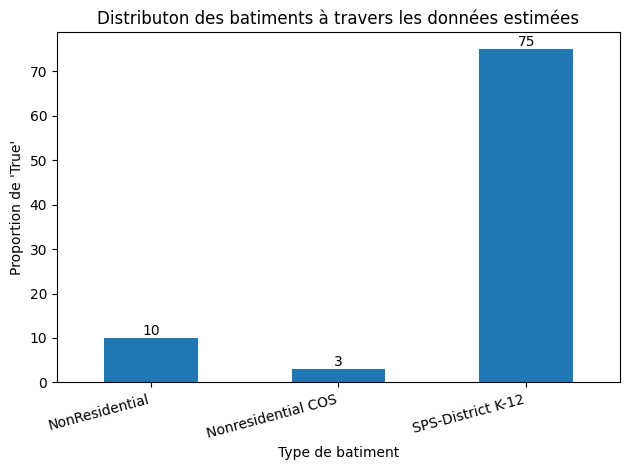

In [ ]:
# On observe la repartition des données éstimées parmi les surfaces et les batiments, pour constater si il y a, ou non, concentration.
# On instancie le regroupement des batiments sur les données éstimées.
distri_dd = (
    df_NonResidential[df_NonResidential['DefaultData']== 1]
    .groupby('BuildingType')['DefaultData']
    .count())

# Diagramme en barre
ax = distri_dd.plot(kind = 'bar')
ax.bar_label(ax.containers[0])
plt.title("Distributon des batiments à travers les données estimées")
plt.xlabel("Type de batiment")
plt.ylabel("Proportion de 'True'")
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.show()

In [41]:
df_NonResidential['BuildingType'].value_counts()

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

In [ ]:
total_sps = (df_NonResidential['BuildingType'] == 'SPS-District K-12').sum()
total_sps_dd = total_sps

np.int64(98)